# Célula 1 — Imports

In [158]:
from pathlib import Path
import random
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
 
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
 
import yfinance as yf
import requests
from arch import arch_model

# Célula 2 — Constantes 

In [159]:
START          = "2003-01-02"
END            = "2025-04-14"
TEST_RATIO     = 0.1
SEED           = 42
WINDOW_SIZE    = 20       
VOL_WINDOW     = 5    # era 21
VOL_SHIFT      = -5   # era -21
 
FRED_API_KEY   = "a75bdc9f7da239a5e3d6c8e389345bfb"
DATA_BASE_PATH = Path("./data")
 
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Célula 3 - Requição para API do FRED

In [160]:
def get_fred_series(series_id: str, start: str, end: str, api_key: str) -> pd.DataFrame:
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start,
        "observation_end": end,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["observations"]
    df = pd.DataFrame(data)[["date", "value"]]
    df.columns = ["timestamp", series_id.lower()]
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df[series_id.lower()] = pd.to_numeric(df[series_id.lower()], errors="coerce")
    return df.reset_index(drop=True)
 
dfii10 = get_fred_series("DFII10", START, END, FRED_API_KEY)
dfii10 = dfii10.rename(columns={"dfii10": "inflation"})
print(dfii10.shape)
print(dfii10.head())

(5813, 2)
   timestamp  inflation
0 2003-01-02       2.43
1 2003-01-03       2.43
2 2003-01-06       2.46
3 2003-01-07       2.42
4 2003-01-08       2.29


# Células 4, 5, 6 e 7 - Carrega dataframes

In [161]:
petrodolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_5_daily_prices_fx.csv",
    parse_dates=["date"]
)
petrodolar = petrodolar.rename(columns={"date": "timestamp"})
petrodolar = petrodolar[[
    "timestamp",
    "brent_crude_usd",
    "wti_crude_usd",
    "brent_wti_spread",
    "usd_dxy_index",
    "eur_usd",
    "usd_rub",
]]
petrodolar = petrodolar[
    (petrodolar["timestamp"] >= START) &
    (petrodolar["timestamp"] <= END)
].reset_index(drop=True)

print(petrodolar.shape)
print(petrodolar.head())

(5813, 7)
   timestamp  brent_crude_usd  wti_crude_usd  brent_wti_spread  usd_dxy_index  \
0 2003-01-02            26.19          21.97              4.22          88.12   
1 2003-01-03            26.42          23.12              3.30          91.02   
2 2003-01-06            26.41          20.85              5.56          90.50   
3 2003-01-07            26.55          23.85              2.70          91.27   
4 2003-01-08            26.25          25.34              0.91          88.42   

   eur_usd  usd_rub  
0   1.1774    29.36  
1   1.1339    28.74  
2   1.1454    28.83  
3   1.1356    29.47  
4   1.1658    28.74  


In [162]:
opec = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_2_opec_quotas_events.csv",
    parse_dates=["date"]
)
opec = opec.rename(columns={"date": "timestamp"})
opec["timestamp"] = pd.to_datetime(opec["timestamp"])
opec = opec[[
    "timestamp",
    "opec_compliance_pct",
    "oil_market_balance_mbd",
    "us_shale_production_mbd",
]].copy()

# Dataset 4 — Dedolarização
dedolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_4_dedollarization.csv",
    parse_dates=["date"]
)
dedolar = dedolar.rename(columns={"date": "timestamp"})
dedolar["timestamp"] = pd.to_datetime(dedolar["timestamp"])
dedolar = dedolar[[
    "timestamp",
    "de_dollarization_pressure_index",
    "brics_gold_reserves_tonnes",
    "usd_global_fx_reserves_pct",
]].copy()

# Dataset 3 — SWF (anual)
swf = pd.read_csv(DATA_BASE_PATH / "petrodollar_3_recycling_swf.csv")
swf = swf[["year", "global_fx_reserves_gold_share_pct"]].copy()

print("OPEC:", opec.shape)
print("Dedolar:", dedolar.shape)
print("SWF:", swf.shape)

OPEC: (312, 4)
Dedolar: (252, 4)
SWF: (26, 2)


In [163]:
tickers = {
    "dxy":   "DX-Y.NYB",
    "vix":   "^VIX",
    "oil":   "CL=F",
    "tips":  "TIP",
    "sp500": "^GSPC",
    "tnx": "^TNX",
}

dfs = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = name
    dfs[name] = close

externos = pd.concat(dfs.values(), axis=1)
externos.index.name = "timestamp"
externos = externos.reset_index()

print(externos.shape)
print(externos.head())

(5623, 7)
   timestamp         dxy        vix        oil  tips       sp500    tnx
0 2003-01-02  102.980003  25.389999  31.850000   NaN  909.030029  4.032
1 2003-01-03  102.470001  24.680000  33.080002   NaN  908.590027  4.038
2 2003-01-06  101.970001  24.910000  32.099998   NaN  929.010010  4.066
3 2003-01-07  102.570000  25.129999  31.080000   NaN  922.929993  4.025
4 2003-01-08  101.870003  25.530001  30.559999   NaN  909.929993  3.981


In [164]:
gold      = pd.read_csv(DATA_BASE_PATH / "final_gold_data.csv",      sep=";", encoding="utf-8", parse_dates=["timestamp"])
palladium = pd.read_csv(DATA_BASE_PATH / "final_palladium_data.csv", sep=";", encoding="utf-8", parse_dates=["timestamp"])
platinum  = pd.read_csv(DATA_BASE_PATH / "final_platinum_data.csv",  sep=";", encoding="utf-8", parse_dates=["timestamp"])
silver    = pd.read_csv(DATA_BASE_PATH / "final_silver_data.csv",    sep=";", encoding="utf-8", parse_dates=["timestamp"])

cols_to_drop = ["currency", "unit", "headlines"]
for name, df in [("palladium", palladium), ("platinum", platinum), ("silver", silver)]:
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    df.rename(columns={
        "open":   f"{name}_open",
        "high":   f"{name}_high",
        "low":    f"{name}_low",
        "close":  f"{name}_close",
        "volume": f"{name}_volume",
    }, inplace=True)

print("Gold:", gold.shape)

Gold: (6177, 9)


# Célula 8 - Merges

In [165]:
for df in [gold, palladium, platinum, silver, externos]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

gold = gold.merge(palladium,  on="timestamp", how="left")
gold = gold.merge(platinum,   on="timestamp", how="left")
gold = gold.merge(silver,     on="timestamp", how="left")
gold = gold.merge(externos,   on="timestamp", how="left")
gold = gold.merge(dfii10,     on="timestamp", how="left")
gold = gold.merge(petrodolar, on="timestamp", how="left")

# Merge mensal: OPEC e dedolarização (merge por ano+mês)
gold["year"]  = gold["timestamp"].dt.year
gold["month_"] = gold["timestamp"].dt.month

opec["year"]   = opec["timestamp"].dt.year
opec["month_"] = opec["timestamp"].dt.month
opec = opec.drop(columns=["timestamp"])

dedolar["year"]   = dedolar["timestamp"].dt.year
dedolar["month_"] = dedolar["timestamp"].dt.month
dedolar = dedolar.drop(columns=["timestamp"])

gold = gold.merge(opec,    on=["year", "month_"], how="left")
gold = gold.merge(dedolar, on=["year", "month_"], how="left")
gold = gold.merge(swf,     on="year",             how="left")
gold = gold.drop(columns=["year", "month_"])

fill_cols = [
    "dxy", "vix", "oil", "tips", "sp500", "tnx",
    "palladium_close", "palladium_open", "palladium_high", "palladium_low",
    "platinum_close",  "platinum_open",  "platinum_high",  "platinum_low",
    "silver_close",    "silver_open",    "silver_high",    "silver_low",
    "inflation",
    "brent_crude_usd", "wti_crude_usd", "brent_wti_spread", "usd_dxy_index", "eur_usd", "usd_rub",
    "opec_compliance_pct", "oil_market_balance_mbd", "us_shale_production_mbd",
    "de_dollarization_pressure_index", "brics_gold_reserves_tonnes", "usd_global_fx_reserves_pct",
    "global_fx_reserves_gold_share_pct",
]

gold[fill_cols] = gold[fill_cols].ffill().bfill()
gold = gold.dropna()

print("Shape após merge:", gold.shape)
print(gold.isna().sum()[gold.isna().sum() > 0])

Shape após merge: (5229, 44)
Series([], dtype: int64)


# Célula 9 - Feature Engineering

In [166]:
gold["day_variation"]  = gold["open"] - gold["close"]
gold["tomorrow_close"] = gold["close"].shift(-1)
gold = gold.dropna(subset=["tomorrow_close"])
 
gold["target_return"] = (gold["tomorrow_close"] - gold["close"]) / gold["close"]
gold["month"]         = gold["timestamp"].dt.month
 
gold["sma_5"]     = gold["close"].rolling(5).mean()
gold["sma_20"]    = gold["close"].rolling(20).mean()
gold["sma_ratio"] = gold["sma_5"] / gold["sma_20"]   # <- adimensional, mantida
 
ema_12 = gold["close"].ewm(span=12).mean()
ema_26 = gold["close"].ewm(span=26).mean()
gold["macd"]        = ema_12 - ema_26
gold["macd_signal"] = gold["macd"].ewm(span=9).mean()
 
rolling_std         = gold["close"].rolling(20).std()
gold["bb_position"] = (gold["close"] - (gold["sma_20"] - 2*rolling_std)) / (4 * rolling_std)  # adimensional [0,1]
 
gold["roc_10"] = gold["close"].pct_change(10)
 
gold["real_rate_proxy"] = gold["tnx"] - gold["inflation"]
gold["petrodolar_brent"] = gold["brent_crude_usd"] / gold["usd_dxy_index"]
gold["brent_roc_20"]     = gold["brent_crude_usd"].pct_change(20)
gold["brent_vol_20"]     = gold["brent_crude_usd"].pct_change().rolling(20).std()
gold["close_return"] = gold["close"].pct_change()
 
delta    = gold["close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs       = avg_gain / avg_loss
gold["rsi_14"] = 100 - (100 / (1 + rs))
 
gold["log_return"] = np.log(gold["close"] / gold["close"].shift(1))

gold["target_vol_5d"] = gold["log_return"].rolling(VOL_WINDOW).std().shift(VOL_SHIFT)
 
gold = gold.dropna()
print("Shape após feature engineering:", gold.shape)
print("NaN restantes:", gold.isna().sum().sum())


Shape após feature engineering: (5203, 63)
NaN restantes: 0


In [167]:
# Fit GARCH no treino completo e extrair volatilidade condicional
log_ret = gold["log_return"].dropna() * 100
garch_full = arch_model(log_ret, vol="Garch", p=1, q=1)
res_full = garch_full.fit(disp="off")

gold_aligned = gold[gold["log_return"].notna()].copy()
gold_aligned["garch_vol"] = res_full.conditional_volatility.values / 100

gold = gold.merge(
    gold_aligned[["timestamp", "garch_vol"]],
    on="timestamp", how="left"
)

# Célula 10 - Target

In [168]:
TARGET = "target_vol_5d"
 
to_drop = [
    "currency", "unit", "timestamp", "headlines",
    "tomorrow_close", "target_return", "log_return",
    "close"
]
 
# MELHORIA 2: removidas features em nível absoluto de preço
cols_to_remove = [
    # Nível absoluto de preço -> leakage indireto via autocorrelação do close
    "sma_5",         # substituída por sma_ratio
    "sma_20",        # substituída por sma_ratio
    "bb_upper",      # substituída por bb_position
    "bb_lower",      # substituída por bb_position
    "high", "low", "open",   # em nível — usar só close como âncora temporal
 
    # Redundâncias conhecidas
    "wti_crude_usd",
    "petrodolar_wti",
    "usd_dxy_index",   # duplicata do dxy
    "max_diff",
    "silver_low",
    "platinum_volume",
    "palladium_volume",
]
 
X = gold.drop(columns=[c for c in to_drop + [TARGET] + cols_to_remove if c in gold.columns])
y = gold[TARGET]
 
n_features = X.shape[1]
print("Features restantes:", list(X.columns))
print("n_features:", n_features)

Features restantes: ['volume', 'palladium_open', 'palladium_high', 'palladium_low', 'palladium_close', 'platinum_open', 'platinum_high', 'platinum_low', 'platinum_close', 'silver_open', 'silver_high', 'silver_close', 'silver_volume', 'dxy', 'vix', 'oil', 'tips', 'sp500', 'tnx', 'inflation', 'brent_crude_usd', 'brent_wti_spread', 'eur_usd', 'usd_rub', 'opec_compliance_pct', 'oil_market_balance_mbd', 'us_shale_production_mbd', 'de_dollarization_pressure_index', 'brics_gold_reserves_tonnes', 'usd_global_fx_reserves_pct', 'global_fx_reserves_gold_share_pct', 'day_variation', 'month', 'sma_ratio', 'macd', 'macd_signal', 'bb_position', 'roc_10', 'real_rate_proxy', 'petrodolar_brent', 'brent_roc_20', 'brent_vol_20', 'close_return', 'rsi_14', 'garch_vol']
n_features: 45


In [169]:
split_idx = int(len(gold) * (1 - TEST_RATIO))
 
vix_train = gold["vix"].iloc[:split_idx].values
vix_test  = gold["vix"].iloc[split_idx:].values
y_train_bl = y.iloc[:split_idx].values
y_test_bl  = y.iloc[split_idx:].values
 
# Regressão linear simples VIX → target_vol
ridge_bl = Ridge(alpha=1.0)
ridge_bl.fit(vix_train.reshape(-1, 1), y_train_bl)
vix_pred_test = ridge_bl.predict(vix_test.reshape(-1, 1))
 
r2_vix  = r2_score(y_test_bl, vix_pred_test)
mae_vix = mean_absolute_error(y_test_bl, vix_pred_test)
print(f"\n── Baseline VIX -> vol ──")
print(f"  R²  (teste): {r2_vix:.4f}")
print(f"  MAE (teste): {mae_vix:.6f}")
print(f"  Correlação : {np.corrcoef(y_test_bl, vix_pred_test)[0,1]:.4f}")
print("  (O LSTM precisa superar esse baseline para justificar sua complexidade)")



── Baseline VIX -> vol ──
  R²  (teste): 0.0176
  MAE (teste): 0.002936
  Correlação : 0.1701
  (O LSTM precisa superar esse baseline para justificar sua complexidade)


# Célula 11 - Create sequences

In [170]:
# Célula 7 — Sequences + split
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y.iloc[i + window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X.to_numpy(), y, WINDOW_SIZE)

mask  = ~np.isnan(y_seq)
X_seq = X_seq[mask]
y_seq = y_seq[mask]

print("NaN em y_seq após mask:", np.isnan(y_seq).sum())

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_seq, y_seq, test_size=TEST_RATIO, shuffle=False
)

print("Train:", X_train_full.shape, "Test:", X_test.shape)

NaN em y_seq após mask: 0
Train: (4664, 20, 45) Test: (519, 20, 45)


# Célula 12 - Criação do modelo

In [171]:
def build_model(learning_rate=0.0001):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, n_features)),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate), loss="huber")
    return model

# Célula 13 - Normalização

In [172]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(
    X_train_full.reshape(-1, n_features)
).reshape(X_train_full.shape)
X_test_scaled = x_scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_full.reshape(-1, 1)).ravel()

print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled mean:", y_train_scaled.mean(), "std:", y_train_scaled.std())

X_train_scaled: (4664, 20, 45)
y_train_scaled mean: 4.875078804528989e-17 std: 1.0


# Célula 14 - Separação em treino e teste

In [173]:
tscv = TimeSeriesSplit(n_splits=5)
folds = list(tscv.split(X_seq))   # materializa todos os folds
 
walk_r2s = []
val_X_final, val_y_final = None, None  # será o último fold — usado no treino final
 
for fold, (train_idx, val_idx) in enumerate(folds):
    X_tr = X_seq[train_idx];  X_va = X_seq[val_idx]
    y_tr = y_seq[train_idx];  y_va = y_seq[val_idx]
 
    sc_x = StandardScaler()
    X_tr_s = sc_x.fit_transform(X_tr.reshape(-1, n_features)).reshape(X_tr.shape)
    X_va_s = sc_x.transform(X_va.reshape(-1, n_features)).reshape(X_va.shape)
 
    sc_y = StandardScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).ravel()
    y_va_s = sc_y.transform(y_va.reshape(-1, 1)).ravel()
 
    tf.keras.backend.clear_session()
    m = build_model()
    m.fit(
        X_tr_s, y_tr_s,
        epochs=100, batch_size=32,
        validation_data=(X_va_s, y_va_s),   # <- explícito, não validation_split
        shuffle=False, verbose=0,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)]
    )
 
    pred_s = m.predict(X_va_s, verbose=0)
    pred   = sc_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    r2 = r2_score(y_va, pred)
    walk_r2s.append(r2)
    print(f"Fold {fold+1} R²: {r2:.4f}  |  pred_std: {pred.std():.6f}  |  real_std: {y_va.std():.6f}")
 
    if fold == len(folds) - 1:
        val_X_final = X_va_s.copy()
        val_y_final = y_va_s.copy()
 
print(f"\nR² médio walk-forward: {np.mean(walk_r2s):.4f}")

Fold 1 R²: -0.0189  |  pred_std: 0.001040  |  real_std: 0.012741
Fold 2 R²: -0.3497  |  pred_std: 0.002457  |  real_std: 0.006255
Fold 3 R²: -0.1283  |  pred_std: 0.001482  |  real_std: 0.003641
Fold 4 R²: 0.1433  |  pred_std: 0.001615  |  real_std: 0.005374
Fold 5 R²: -0.0581  |  pred_std: 0.001522  |  real_std: 0.003672

R² médio walk-forward: -0.0823


# Célula 15 - Treino

In [174]:
tf.keras.backend.clear_session()
final_model = build_model()
 
early_stop = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True, min_delta=1e-5
)
 
history = final_model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(val_X_final, val_y_final),  
    epochs=300,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1,
)


Epoch 1/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.3015 - val_loss: 0.1959
Epoch 2/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2752 - val_loss: 0.1513
Epoch 3/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2626 - val_loss: 0.1380
Epoch 4/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2555 - val_loss: 0.1330
Epoch 5/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2527 - val_loss: 0.1319
Epoch 6/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2473 - val_loss: 0.1317
Epoch 7/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2408 - val_loss: 0.1309
Epoch 8/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2408 - val_loss: 0.1312
Epoch 9/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2386 - val_loss: 0.1313
Epoch 10/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2354 - val_loss: 0.1308
Epoch 11/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2355 - val_loss: 0.1301
Epoch 12/300
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 

In [175]:
print("y_train_scaled mean:", y_train_scaled.mean())
print("y_train_scaled std: ", y_train_scaled.std())
print("y_train_scaled min: ", y_train_scaled.min())
print("y_train_scaled max: ", y_train_scaled.max())
print("NaN em y_train_scaled:", np.isnan(y_train_scaled).sum())
print("NaN em X_train_scaled:", np.isnan(X_train_scaled).sum())

y_train_scaled mean: 4.875078804528989e-17
y_train_scaled std:  1.0
y_train_scaled min:  -1.2219077119020514
y_train_scaled max:  16.201674901672078
NaN em y_train_scaled: 0
NaN em X_train_scaled: 0


In [176]:
nan_cols = X.columns[X.isna().any()].tolist()
print("Colunas com NaN:", nan_cols)
print(X[nan_cols].isna().sum())

Colunas com NaN: []
Series([], dtype: float64)


# Célula 16 - Métricas

In [177]:
y_pred_train = y_scaler.inverse_transform(
    final_model.predict(X_train_scaled)
).flatten()
y_pred_test = y_scaler.inverse_transform(
    final_model.predict(X_test_scaled)
).flatten()
 
print("Pred treino std:", y_pred_train.std())
print("Real treino std:", y_train_full.std())
print("Pred teste  std:", y_pred_test.std())
print("Real teste  std:", y_test.std())
 
for name, y_true, y_pred in [
    ("TRAIN", y_train_full, y_pred_train),
    ("TEST",  y_test,       y_pred_test),
]:
    print(f"\n{'='*60}\n{name} METRICS\n{'='*60}")
    print("MAE:  ", mean_absolute_error(y_true, y_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:   ", r2_score(y_true, y_pred))
    baseline = np.full_like(y_true, fill_value=y_train_full.mean())
    print("R2 baseline (média):", r2_score(y_true, baseline))
    print("R2 baseline (VIX)  :", r2_vix, "<- barra real a superar")
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print("Correlação pred vs real:", corr)

146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Pred treino std: 0.0035896173
Real treino std: 0.00723237649700154
Pred teste  std: 0.00092225976
Real teste  std: 0.0037437583227989354

TRAIN METRICS
MAE:   0.0027498146535448963
RMSE:  0.005416570026209326
R2:    0.43909840899435715
R2 baseline (média): 0.0
R2 baseline (VIX)  : 0.017607539131068495 <- barra real a superar
Correlação pred vs real: 0.6922413593421459

TEST METRICS
MAE:   0.002683300193143227
RMSE:  0.0036628170159949966
R2:    0.0427732299154705
R2 baseline (média): -0.09314560490839274
R2 baseline (VIX)  : 0.017607539131068495 <- barra real a superar
Correlação pred vs real: 0.27977672133131776


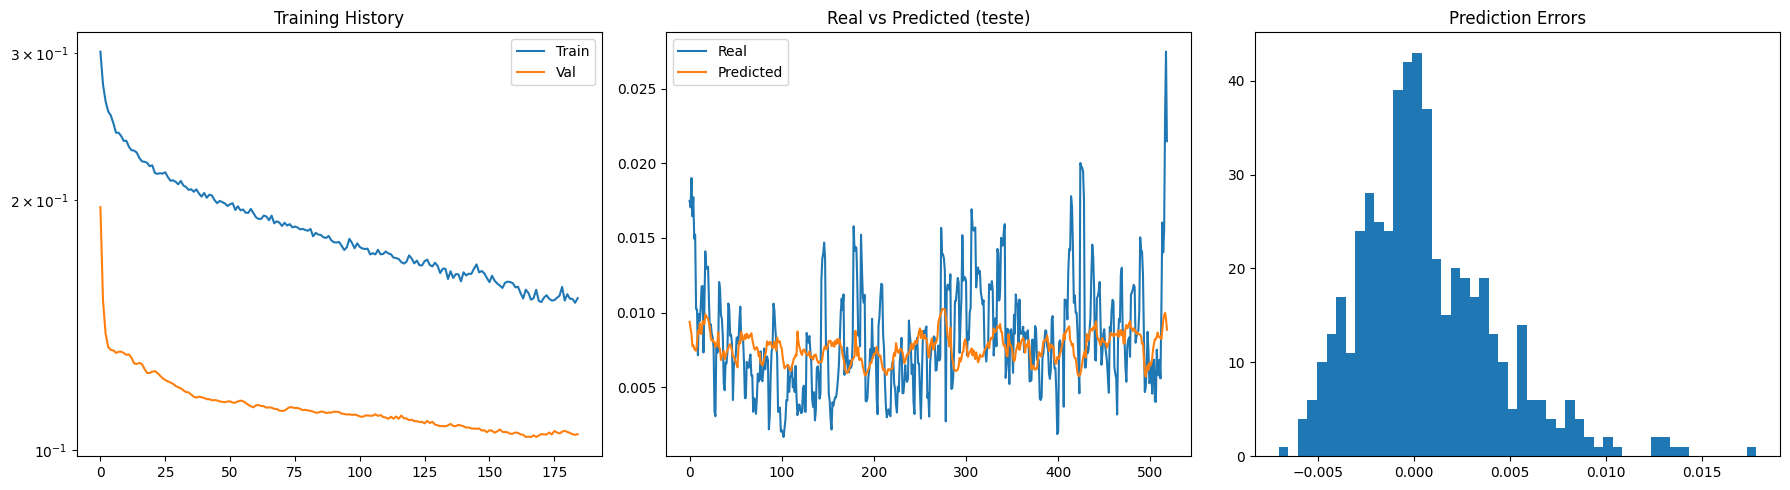


── Correlações com o target (novo) ──
garch_vol                            0.366958
vix                                  0.280610
eur_usd                              0.205263
dxy                                 -0.177667
usd_rub                             -0.153726
oil_market_balance_mbd               0.142668
us_shale_production_mbd             -0.132078
platinum_high                        0.131336
platinum_close                       0.130686
platinum_open                        0.130584
platinum_low                         0.129817
global_fx_reserves_gold_share_pct   -0.117390
petrodolar_brent                     0.117275
sp500                               -0.112847
macd_signal                          0.110727
Name: target, dtype: float64


In [178]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_yscale("log")
axes[0].set_title("Training History")
axes[0].legend()
 
axes[1].plot(y_test,                label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted (teste)")
axes[1].legend()
 
errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")
 
plt.tight_layout()
plt.show()
 
print("\n── Correlações com o target (novo) ──")
corr_df = pd.DataFrame(X.values, columns=X.columns)
corr_df["target"] = y.values[:len(corr_df)]
correlations = corr_df.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
print(correlations.head(15))


In [179]:
print(pd.Series(y).autocorr(1))
print(pd.Series(y).autocorr(5))
print(pd.Series(y).autocorr(20))

0.8328093669961432
0.21446319338034475
0.22733619905882765


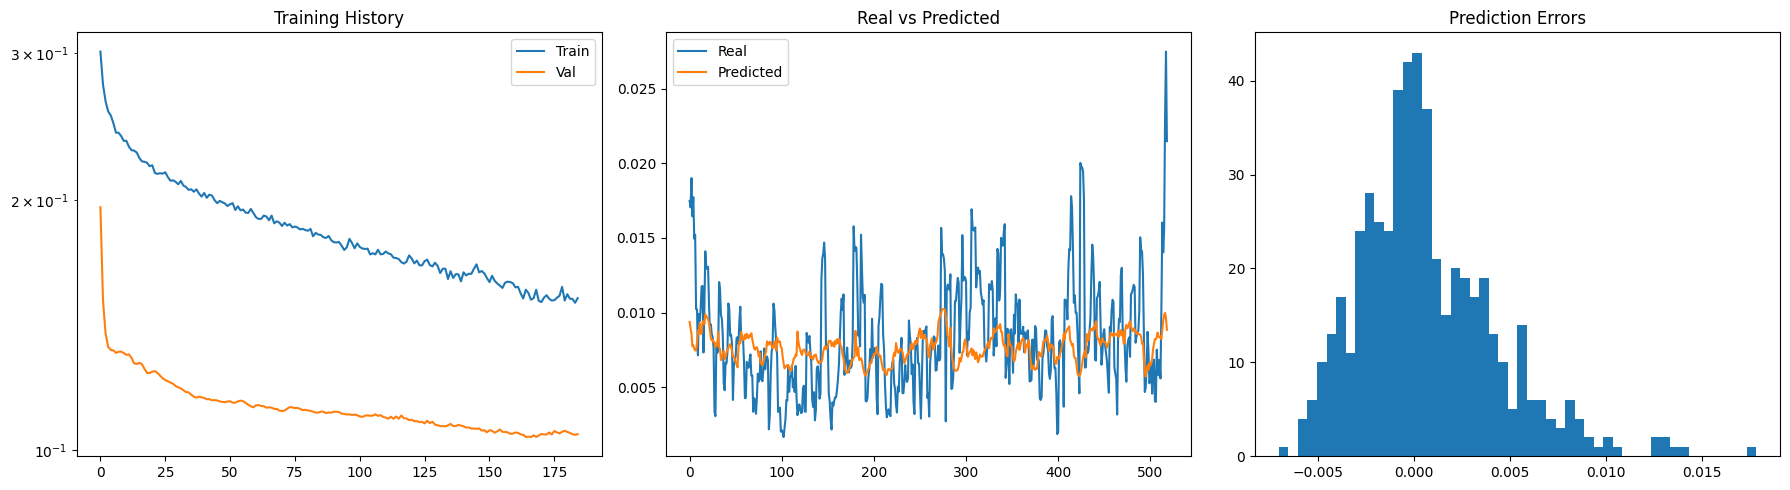

In [180]:
# Célula 12 — Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_yscale('log')
axes[0].set_title("Training History")
axes[0].legend()

axes[1].plot(y_test,                label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted")
axes[1].legend()

errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")

plt.tight_layout()
plt.show()

In [181]:
# Célula 13 — Diagnóstico de correlações
corr = pd.DataFrame(X.values, columns=X.columns)
corr["target"] = y.values[:len(corr)]
correlations = corr.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
correlations

garch_vol                            0.366958
vix                                  0.280610
eur_usd                              0.205263
dxy                                 -0.177667
usd_rub                             -0.153726
oil_market_balance_mbd               0.142668
us_shale_production_mbd             -0.132078
platinum_high                        0.131336
platinum_close                       0.130686
platinum_open                        0.130584
platinum_low                         0.129817
global_fx_reserves_gold_share_pct   -0.117390
petrodolar_brent                     0.117275
sp500                               -0.112847
macd_signal                          0.110727
brics_gold_reserves_tonnes          -0.108605
opec_compliance_pct                 -0.101606
de_dollarization_pressure_index     -0.092711
palladium_low                       -0.088173
tips                                -0.087901
palladium_close                     -0.087634
palladium_open                    

In [182]:
print("Período completo:", gold["timestamp"].min(), "→", gold["timestamp"].max())
print("Linhas total:", len(gold))
print("\nÚltimas datas do treino (aprox):")
print("Treino vai até ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])
print("Teste começa em ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])

Período completo: 2000-09-28 00:00:00 → 2025-04-04 00:00:00
Linhas total: 5203

Últimas datas do treino (aprox):
Treino vai até ~ 2023-03-10 00:00:00
Teste começa em ~ 2023-03-10 00:00:00


In [183]:
y_train_full.std(), y_test.std()

(np.float64(0.00723237649700154), np.float64(0.0037437583227989354))

In [184]:
df = pd.DataFrame({
    "Return": y_train_full.flatten()
})
df["Return"].autocorr(lag=1)

np.float64(0.8335171863873533)

In [185]:
df["Return"].autocorr(lag=5)

np.float64(0.2134231002045999)

In [186]:
df["Return"].autocorr(lag=10)

np.float64(0.17449769033487653)

In [187]:
df["Return"].autocorr(lag=20)

np.float64(0.2255578282898496)

In [188]:
y.describe()

count    5203.000000
mean        0.009385
std         0.006964
min         0.000672
25%         0.005669
50%         0.008095
75%         0.011222
max         0.126686
Name: target_vol_5d, dtype: float64

In [189]:
print(y.std())

0.006963986301010771


In [190]:
print("Pred treino std:", y_pred_train.std())
print("Pred teste std:", y_pred_test.std())

print("Real treino std:", y_train_full.std())
print("Real teste std:", y_test.std())

Pred treino std: 0.0035896173
Pred teste std: 0.00092225976
Real treino std: 0.00723237649700154
Real teste std: 0.0037437583227989354


In [191]:
correlations

garch_vol                            0.366958
vix                                  0.280610
eur_usd                              0.205263
dxy                                 -0.177667
usd_rub                             -0.153726
oil_market_balance_mbd               0.142668
us_shale_production_mbd             -0.132078
platinum_high                        0.131336
platinum_close                       0.130686
platinum_open                        0.130584
platinum_low                         0.129817
global_fx_reserves_gold_share_pct   -0.117390
petrodolar_brent                     0.117275
sp500                               -0.112847
macd_signal                          0.110727
brics_gold_reserves_tonnes          -0.108605
opec_compliance_pct                 -0.101606
de_dollarization_pressure_index     -0.092711
palladium_low                       -0.088173
tips                                -0.087901
palladium_close                     -0.087634
palladium_open                    

In [192]:
for col in externos.columns:
    if col != "timestamp":
        first_valid = externos[col].first_valid_index()

        if first_valid is not None:
            print(
                col,
                externos.loc[first_valid, "timestamp"]
            )

dxy 2003-01-02 00:00:00
vix 2003-01-02 00:00:00
oil 2003-01-02 00:00:00
tips 2003-12-05 00:00:00
sp500 2003-01-02 00:00:00
tnx 2003-01-02 00:00:00


In [193]:
print("y_train")
print(y_tr.mean(), y_tr.std())

print("\ny_pred")
print(pred.mean(), pred.std())

y_train
0.009566980225614124 0.007444846710543908

y_pred
0.008202318 0.0015220842


In [194]:
from arch import arch_model
log_ret = gold["log_return"].dropna() * 100  
garch = arch_model(log_ret, vol="Garch", p=1, q=1)
res = garch.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7580.53
Distribution:                  Normal   AIC:                           15169.1
Method:            Maximum Likelihood   BIC:                           15195.3
                                        No. Observations:                 5203
Date:                seg, jun 08 2026   Df Residuals:                     5202
Time:                        20:27:13   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0273  1.376e-02      1.987  4.696e-02 [3.

In [ ]:
from arch import arch_model
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

log_ret = gold["log_return"].dropna() * 100

n_test = int(len(log_ret) * TEST_RATIO)
train_ret = log_ret.iloc[:-n_test]
test_ret  = log_ret.iloc[-n_test:]

preds = []
for i in range(len(test_ret)):
    window = log_ret.iloc[:len(train_ret) + i]
    m = arch_model(window, vol="Garch", p=1, q=1)
    r = m.fit(disp="off", show_warning=False)
    f = r.forecast(horizon=1)
    preds.append(np.sqrt(f.variance.values[-1, 0]) / 100)

realized = test_ret.values / 100
realized_vol = pd.Series(realized).rolling(5).std().shift(-5).dropna().values
preds_aligned = np.array(preds[:len(realized_vol)])

print("GARCH R² no teste:", r2_score(realized_vol, preds_aligned))